##  **Détection DDoS : Un Système de Détection Multiclasse et Multidimensionnel avec Divers Modèles de Machine Learning**

---

###  **Aperçu du Projet**

Ce projet vise à construire un système capable de **détecter et classifier** les attaques **DDoS (Déni de Service Distribué)** en utilisant le jeu de données **CICDDoS2019**. L'objectif est de développer un modèle de **classification multiclasse** capable d'identifier différents types d'attaques DDoS à partir du trafic réseau normal. Le jeu de données comprend plusieurs types d'attaques ayant des caractéristiques de trafic réseau différentes, ce qui en fait un problème complexe pour la détection DDoS.

---

###  **Description du Jeu de Données**

Le jeu de données **CICDDoS2019**, fourni par l'Institut Canadien pour la Cybersécurité (CIC), contient des données de trafic réseau représentant plusieurs types d'attaques DDoS ainsi que du trafic bénin (non-attaque). Le jeu de données comporte plusieurs attributs comme la taille des paquets, les adresses IP source/destination et les types de protocoles. La variable cible est composée de différentes étiquettes d'attaques :

| Étiquette | Description |
|-----------|-------------|
| **Syn** | Attaque par inondation SYN |
| **Benign** | Trafic normal (non-attaque) |
| **UDP** | Attaque par inondation UDP générique |
| **MSSQL** | Attaque DDoS spécifique à MSSQL |
| **NetBIOS** | Attaque DDoS liée à NetBIOS |
| **LDAP** | Attaque basée sur le protocole LDAP |

---

###  **Aperçu du Processus**

####  **Collecte et Prétraitement des Données**

1. **Collecte des Chemins des Données** :
   - Les chemins des ensembles d'entraînement et de test sont collectés en parcourant les dossiers.
   - On s'assure que seuls les ensembles de données avec des noms correspondants sont utilisés pour l'entraînement et le test.

2. **Traitement des Données** :
   - **Mappage des Colonnes** : On mappe les noms de colonnes entre les ensembles d'entraînement et de test pour garantir leur cohérence. Les noms de colonnes dans l'ensemble de test sont renommés pour correspondre à ceux de l'ensemble d'entraînement.
   - **Gestion des Valeurs Nulles et Doublons** : On vérifie les valeurs nulles ou les doublons. Aucune valeur nulle n'est trouvée et les doublons sont supprimés.
   - **Suppression des Colonnes à Valeur Unique** : Les colonnes avec une seule valeur unique sont supprimées car elles n'apportent pas d'information utile.
   - **Suppression des Colonnes Fortement Corrélées** : Les colonnes avec un coefficient de corrélation ≥ 0,8 sont supprimées pour réduire la multicolinéarité et améliorer les performances du modèle.

---

###  **Analyse Exploratoire des Données (EDA)**

Plusieurs visualisations clés ont été réalisées pour comprendre le jeu de données :


- **Distribution de la Durée des Flux** :
   - Analyse de la durée des flux pour le trafic DDoS et normal.
- **Longueur Moyenne des Paquets par Protocole et par Attaque** :
   - Exploration de la longueur moyenne des paquets par type de protocole et par type d'attaque.
- **Distribution des Flags par Type d'Attaque** :
   - Distribution des différents types de flags par type d'attaque.
- **Distribution des Demandes par Protocole** :
   - Nombre de requêtes provenant de différents protocoles.
- **Matrice de Corrélation** :
   - Heatmap pour visualiser la matrice de corrélation et identifier les relations entre les caractéristiques.

---

###  **Prétraitement des Données et Ingénierie des Caractéristiques**

- **Division Entraînement/Test** :
   - Le jeu de données est divisé en ensembles d'entraînement, de validation et de test pour assurer une évaluation correcte du modèle.
- **Encodage des Caractéristiques** :
   - La colonne cible est encodée à l'aide de **LabelEncoder** pour convertir les étiquettes catégorielles en valeurs numériques.
- **Mise à l'Échelle des Caractéristiques** :
   - On applique la **Normalisation Min-Max** pour mettre les caractéristiques à l'échelle, améliorant ainsi les performances des algorithmes basés sur la distance.

---

###  **Entraînement et Évaluation du Modèle**

- **Sélection du Modèle** :
   - Plusieurs modèles sont entraînés et évalués pour la classification multiclasse, notamment :
     - **Forêt Aléatoire (Random Forest)**
     - **Extra Trees Classifier**
     - **XGBoost**

- **Évaluation du Modèle** :
   - On évalue les modèles à l'aide de diverses métriques comme la **précision (accuracy)**, la **précision (precision)**, le **rappel (recall)**, le **score F1** et l'**AUC ROC**.
   - Les courbes ROC sont tracées pour comparer les performances de chaque modèle à travers les différentes classes.
   - Un tableau des scores des modèles est créé et affiché pour faciliter la comparaison.

---

###  **Visualisation des Résultats**

- **Comparaison des Modèles** :
   - On trace le **score de précision (accuracy)** pour chaque modèle afin de comparer visuellement leurs performances.
   - Les courbes ROC pour tous les modèles sont tracées pour analyser leur capacité de classification, en particulier pour les tâches de classification multiclasse.

---



BASE = Path(r"E:\CIC-DDoS2019")
SORTIE = BASE / "echantillons"
TMP = SORTIE / "tmp"
TMP.mkdir(parents=True, exist_ok=True)

CAP = 150_000
SEED = 42
CHUNK = 100_000
LIGNES_CIBLE = 3_000_000

COLONNES_A_SUPPRIMER = [
    "Unnamed: 0", "Flow ID", "Source IP", "Source Port",
    "Destination IP", "Destination Port", "Timestamp", "SimillarHTTP",
]

COMPTES = {
    "01-12": {
        "BENIGN": 56863, "DrDoS_DNS": 5071011, "DrDoS_LDAP": 2179930,
        "DrDoS_MSSQL": 4522492, "DrDoS_NTP": 1202642, "DrDoS_NetBIOS": 4093279,
        "DrDoS_SNMP": 5159870, "DrDoS_SSDP": 2610611, "DrDoS_UDP": 3134645,
        "Syn": 1582289, "TFTP": 20082580, "UDP-lag": 366461,
    },
    "03-11": {
        "BENIGN": 56965, "LDAP": 1915122, "MSSQL": 5787453, "NetBIOS": 3657497,
        "Portmap": 186960, "Syn": 4891500, "UDP": 3754680, "UDPLag": 114348,
    },
}

HARMONISATION = {
    "DrDoS_DNS": "DNS", "DrDoS_LDAP": "LDAP", "DrDoS_MSSQL": "MSSQL",
    "DrDoS_NTP": "NTP", "DrDoS_NetBIOS": "NetBIOS", "DrDoS_SNMP": "SNMP",
    "DrDoS_SSDP": "SSDP", "DrDoS_UDP": "UDP", "UDP-lag": "UDPLag",
}


def traiter_fichier(f, journee, proba):
    tmp = TMP / f"{journee}_{f.stem}.parquet"
    if tmp.exists():
        print(f"  [{journee}] {f.name} deja traite, on saute")
        return tmp

    print(f"  [{journee}] lecture de {f.name} ...")
    morceaux = []
    for chunk in pd.read_csv(f, chunksize=CHUNK, low_memory=False):
        chunk.columns = [c.strip() for c in chunk.columns]
        chunk = chunk[chunk["Label"].isin(proba)]
        chunk = chunk.drop(columns=COLONNES_A_SUPPRIMER, errors="ignore")
        cols = [c for c in chunk.columns if c != "Label"]
        chunk[cols] = chunk[cols].apply(pd.to_numeric, errors="coerce")
        chunk = chunk.replace([np.inf, -np.inf], np.nan).dropna()
        if chunk.empty:
            continue

        h = pd.util.hash_pandas_object(chunk, index=False).to_numpy()
        seuil = (chunk["Label"].map(proba).to_numpy() * 10_000).astype("int64")
        chunk = chunk[(h % 10_000) < seuil]

        chunk = chunk.drop_duplicates()
        chunk[cols] = chunk[cols].astype("float32")
        if len(chunk):
            morceaux.append(chunk)
        del chunk

    if not morceaux:
        return None
    df = pd.concat(morceaux, ignore_index=True)
    del morceaux
    df = df.drop_duplicates().reset_index(drop=True)
    df.to_parquet(tmp, index=False)
    print(f"      -> {len(df):,} flux uniques gardes")
    del df
    gc.collect()
    return tmp


def construire(journee):
    proba = {lab: min(1.0, LIGNES_CIBLE / n) for lab, n in COMPTES[journee].items()}

    temporaires = []
    for f in sorted((BASE / journee).rglob("*.csv")):
        t = traiter_fichier(f, journee, proba)
        if t is not None:
            temporaires.append(t)

    df = pd.concat([pd.read_parquet(t) for t in temporaires], ignore_index=True)
    df["Label"] = df["Label"].replace(HARMONISATION)

    avant = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"  [{journee}] doublons supprimes : {avant - len(df):,}")

    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    df = df.groupby("Label", group_keys=False).head(CAP).reset_index(drop=True)

    df["Day"] = journee
    return df


def hash_lignes(df, colonnes):
    return pd.util.hash_pandas_object(df[colonnes], index=False)


if __name__ == "__main__":
    train = construire("01-12")
    test = construire("03-11")

    features = [c for c in train.columns if c not in ("Label", "Day") and c in test.columns]

    h_train = set(hash_lignes(train, features))
    masque = hash_lignes(test, features).isin(h_train)
    print(f"\nLignes du test identiques au train (retirees) : {masque.sum():,}")
    test = test[~masque].reset_index(drop=True)

    for nom, df in [("train_0112", train), ("test_0311", test)]:
        print(f"\n{nom} : {len(df):,} lignes, {df.shape[1]} colonnes")
        print(df["Label"].value_counts().to_string())
        df.to_parquet(SORTIE / f"{nom}.parquet", index=False)
        print(f"Enregistre : {SORTIE / (nom + '.parquet')}")

In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Configuration

In [47]:
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.figure as fig
import matplotlib.cm as cm
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve


from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

import pickle
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Métriques
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')
import warnings
warnings.filterwarnings('ignore')
import os, gc, warnings
import pandas as pd
import numpy as np
from pathlib import Path
warnings.filterwarnings('ignore')

## 2. Chargement des deux fichiers

In [48]:
from google.colab import drive
drive.mount('/content/drive')

train_df = pd.read_parquet(r"/content/drive/MyDrive/DDoS2019/train_0112.parquet")
test_df  = pd.read_parquet(r"/content/drive/MyDrive/DDoS2019/test_0311.parquet")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


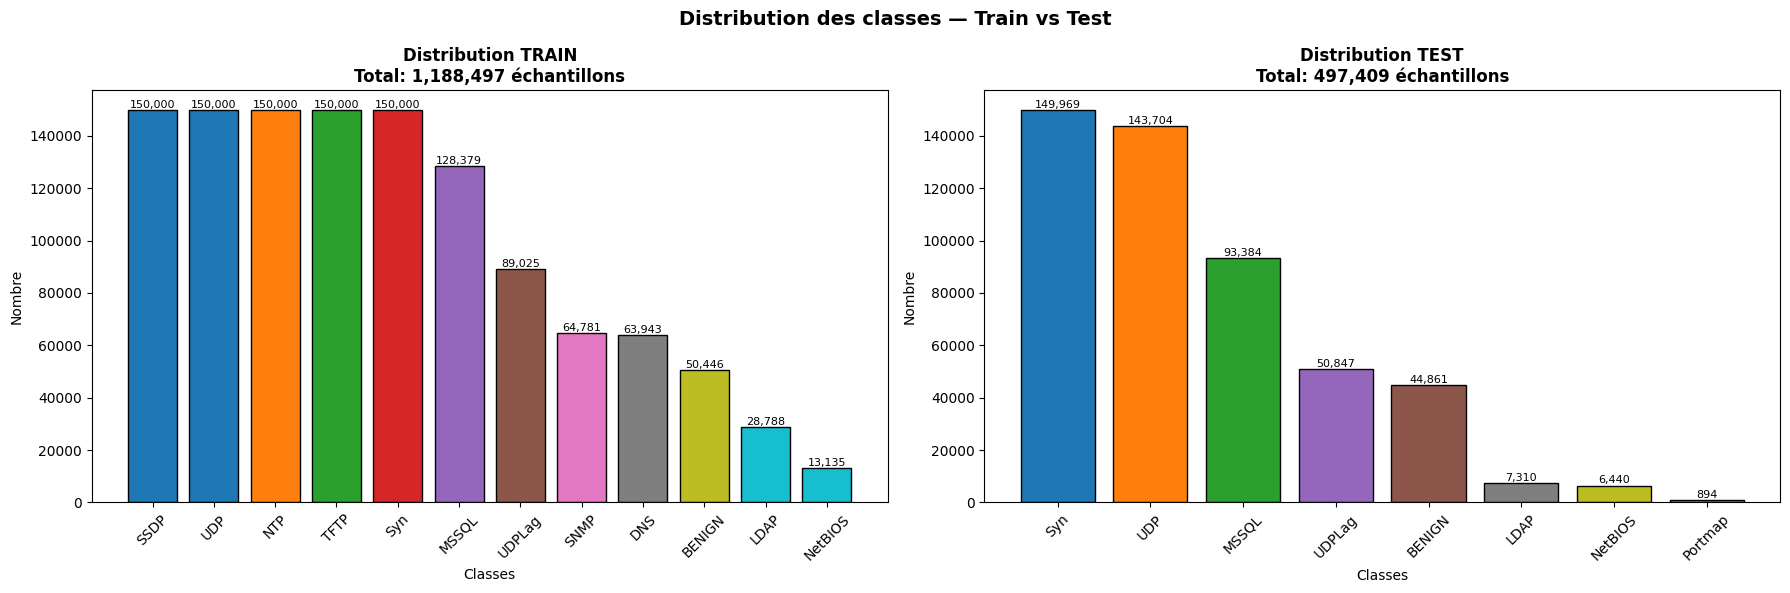

In [49]:
import matplotlib.pyplot as plt
import numpy as np


def plot_distribution(df, ax, titre="Distribution", couleur_seed=0):
    counts = df['Label'].value_counts()
    ax.bar(
        counts.index,
        counts.values,
        color=plt.cm.tab10(np.linspace(0, 1, len(counts))),
        edgecolor='black'
    )
    ax.set_title(f'{titre}\nTotal: {len(df):,} échantillons',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Classes', fontsize=10)
    ax.set_ylabel('Nombre', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    # Ajouter les valeurs au-dessus des barres
    for i, (label, count) in enumerate(counts.items()):
        ax.text(i, count + 100, f'{count:,}', ha='center', va='bottom', fontsize=8)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_distribution(train_df, axes[0], titre="Distribution TRAIN")
plot_distribution(test_df,  axes[1], titre="Distribution TEST")

plt.suptitle('Distribution des classes — Train vs Test',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("distribution_train_test.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Nettoyage commun au train et au test

Chaque valeur calculée (colonnes constantes, médianes, corrélations) vient du **train**, puis est appliquée aux deux jeux. Aucune étape n'utilise l'étiquette.

In [50]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1188497 entries, 0 to 1188496
Data columns (total 81 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Protocol                     1188497 non-null  float32
 1   Flow Duration                1188497 non-null  float32
 2   Total Fwd Packets            1188497 non-null  float32
 3   Total Backward Packets       1188497 non-null  float32
 4   Total Length of Fwd Packets  1188497 non-null  float32
 5   Total Length of Bwd Packets  1188497 non-null  float32
 6   Fwd Packet Length Max        1188497 non-null  float32
 7   Fwd Packet Length Min        1188497 non-null  float32
 8   Fwd Packet Length Mean       1188497 non-null  float32
 9   Fwd Packet Length Std        1188497 non-null  float32
 10  Bwd Packet Length Max        1188497 non-null  float32
 11  Bwd Packet Length Min        1188497 non-null  float32
 12  Bwd Packet Length Mean       1188497 non-n

In [51]:
# Supprimer la colonne Day
train_df = train_df.drop(columns=["Day"])
test_df  = test_df.drop(columns=["Day"])

In [52]:
RENOMMAGE = {
    "Total Length of Fwd Packets": "Fwd Packets Length Total",
    "Total Length of Bwd Packets": "Bwd Packets Length Total",
    "Min Packet Length": "Packet Length Min",
    "Max Packet Length": "Packet Length Max",
    "Average Packet Size": "Avg Packet Size",
    "Init_Win_bytes_forward": "Init Fwd Win Bytes",
    "Init_Win_bytes_backward": "Init Bwd Win Bytes",
    "act_data_pkt_fwd": "Fwd Act Data Packets",
    "min_seg_size_forward": "Fwd Seg Size Min",
}
for d in (train_df, test_df):
    d.columns = d.columns.str.strip()
    d.rename(columns=RENOMMAGE, inplace=True)
assert set(train_df.columns) == set(test_df.columns)
test_df = test_df[train_df.columns]


In [53]:
# colonne dupliquee
if "Fwd Header Length.1" in train_df.columns:
    if (train_df["Fwd Header Length.1"] == train_df["Fwd Header Length"]).all():
        train_df = train_df.drop(columns=["Fwd Header Length.1"])
        test_df = test_df.drop(columns=["Fwd Header Length.1"])
        print("Colonne dupliquee Fwd Header Length.1 supprimee")

Colonne dupliquee Fwd Header Length.1 supprimee


In [54]:
# Afficher les colonnes avec une seule valeur unique
for i in train_df.columns:
    if train_df[i].nunique() == 1:
        print(i)
colonnes_valeur_unique = [col for col in train_df.columns if train_df[col].nunique() == 1]
print(f"Colonnes avec une seule valeur : {colonnes_valeur_unique}")
#Supprimer les colonnes à valeur unique
train_df = train_df.drop(columns=colonnes_valeur_unique)
test_df = test_df.drop(columns=colonnes_valeur_unique)

Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
FIN Flag Count
PSH Flag Count
ECE Flag Count
Fwd Avg Bytes/Bulk
Fwd Avg Packets/Bulk
Fwd Avg Bulk Rate
Bwd Avg Bytes/Bulk
Bwd Avg Packets/Bulk
Bwd Avg Bulk Rate
Colonnes avec une seule valeur : ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count', 'PSH Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [55]:
# analyse des valeurs infinies
np.isinf(train_df.select_dtypes(include=np.number)).values.sum()

np.int64(0)

In [56]:
# Nombre total de valeurs manquantes
train_df.isnull().sum().sum()

np.int64(0)

In [57]:
print(f" Nombre de lignes dupliquées : {train_df.duplicated().sum()}")

 Nombre de lignes dupliquées : 0


In [58]:
# Vérifier les négatifs
neg_cols = [col for col in train_df.select_dtypes(include=[np.number]).columns if (train_df[col] < 0).sum() > 0]
print(f"Colonnes avec négatifs: {neg_cols}")
print(f"Total négatifs: {sum((train_df[col] < 0).sum() for col in train_df.select_dtypes(include=[np.number]).columns):,}")
def traitement_negative_values(df, verbose=False):
    # -1 remplace 0
    for col in ['Init Fwd Win Bytes', 'Init Bwd Win Bytes']:
        if col in df.columns:
            df.loc[df[col] == -1, col] = 0

    # Négatifs remplace médiane
    for col in ['Fwd Header Length', 'Bwd Header Length', 'Fwd Seg Size Min']:
        if col in df.columns:
            median_val = df[col][df[col] >= 0].median()
            df.loc[df[col] < 0, col] = median_val

    if verbose:
        cols =['Fwd Header Length', 'Bwd Header Length', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 'Fwd Seg Size Min']
        total = sum((df[col] < 0).sum() for col in cols if col in df.columns)
        print(f"Négatifs restants: {total:,}")

    return df
train_df = traitement_negative_values(train_df, verbose=True)
test_df  = traitement_negative_values(test_df,  verbose=True)

Colonnes avec négatifs: ['Fwd Header Length', 'Bwd Header Length', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 'Fwd Seg Size Min']
Total négatifs: 2,302,285
Négatifs restants: 0
Négatifs restants: 0



 Statistiques de Label :
Label
SSDP       150000
UDP        150000
NTP        150000
TFTP       150000
Syn        150000
MSSQL      128379
UDPLag      89025
SNMP        64781
DNS         63943
BENIGN      50446
LDAP        28788
NetBIOS     13135
Name: count, dtype: int64

Pourcentage :
Label
SSDP       12.620983
UDP        12.620983
NTP        12.620983
TFTP       12.620983
Syn        12.620983
MSSQL      10.801794
UDPLag      7.490553
SNMP        5.450666
DNS         5.380157
BENIGN      4.244521
LDAP        2.422219
NetBIOS     1.105177
Name: proportion, dtype: float64


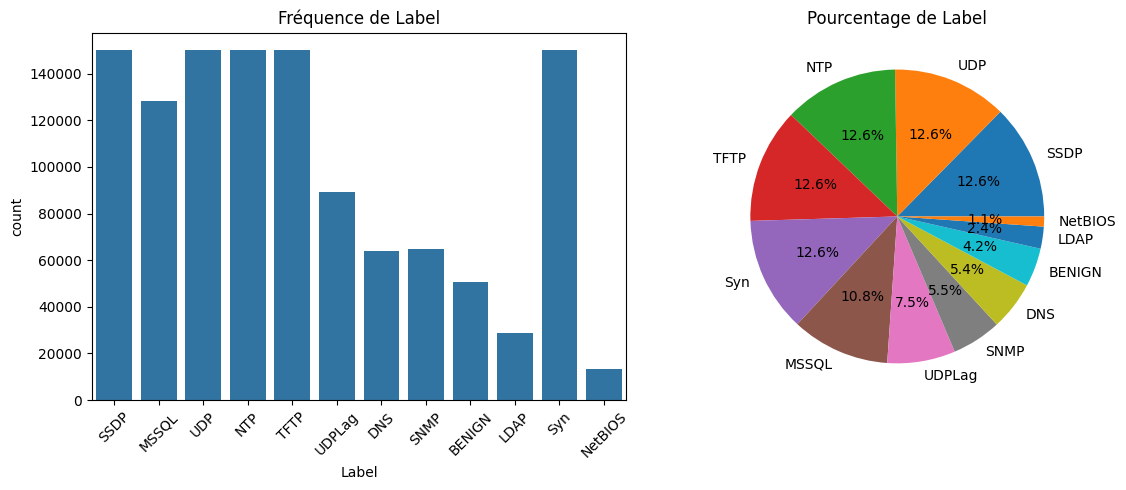

In [59]:
def analyser_colonne_cat(donnees, colonne):

    # Afficher les statistiques
    print(f"\n Statistiques de {colonne} :")
    print(donnees[colonne].value_counts())
    print("\nPourcentage :")
    print(donnees[colonne].value_counts(normalize=True) * 100)

    # Afficher les graphiques
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Diagramme à barres
    sns.countplot(x=colonne, data=donnees, ax=axes[0])
    axes[0].set_title(f'Fréquence de {colonne}')
    axes[0].tick_params(axis='x', rotation=45)

    # Diagramme circulaire
    valeurs = donnees[colonne].value_counts()
    axes[1].pie(valeurs, labels=valeurs.index, autopct='%1.1f%%')
    axes[1].set_title(f'Pourcentage de {colonne}')

    plt.tight_layout()
    plt.show()

analyser_colonne_cat(train_df, 'Label')

# Analyser toutes les colonnes catégorielles
#for col in cat_cols:
    #analyser_colonne_cat(train_df, col)

In [60]:
def plot_boxplot(variable, df):
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="Label", y=variable, data=df)
    plt.yscale('log')
    plt.title(f"Distribution de {variable}", fontsize=14, fontweight='bold')
    plt.xlabel("Type de trafic")
    plt.ylabel(variable)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

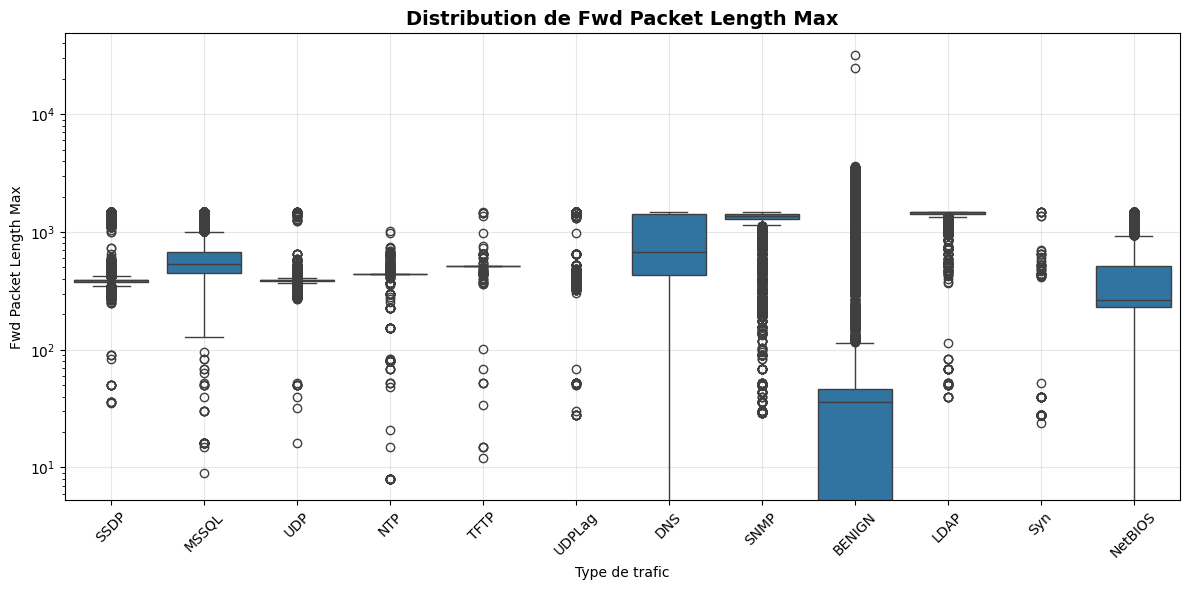

In [61]:
plot_boxplot('Fwd Packet Length Max', train_df)

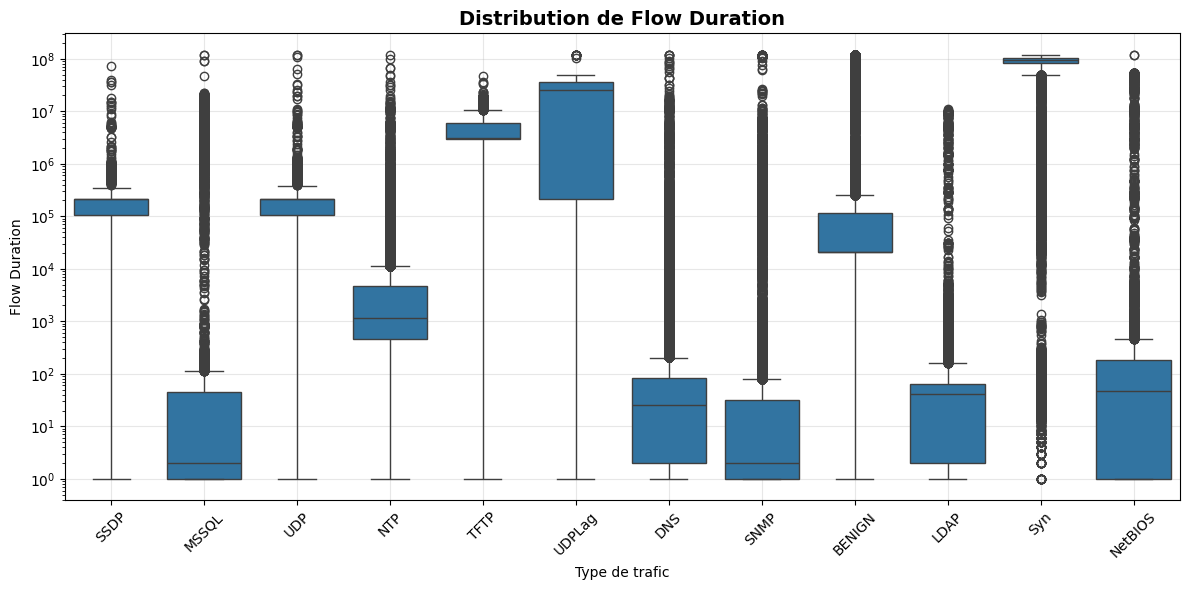

In [62]:
plot_boxplot('Flow Duration', train_df)

Tableau croisé : Protocole vs Attaque
Protocol  0.0     6.0     17.0
Label                         
BENIGN     867   28542   21037
DNS        119     670   63154
LDAP        64     304   28420
MSSQL       23     267  128089
NTP         22     446  149532
NetBIOS     12     514   12609
SNMP        60     620   64101
SSDP         2      63  149935
Syn          3  149967      30
TFTP         3     505  149492
UDP          9     143  149848
UDPLag      13   67371   21641


<Figure size 1200x600 with 0 Axes>

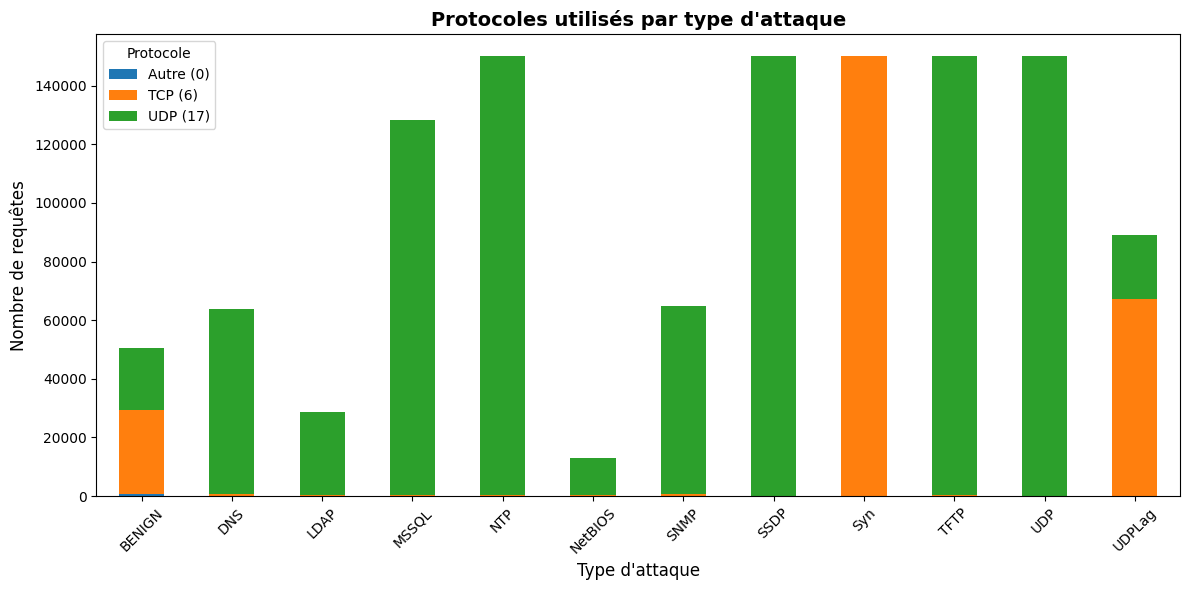

In [63]:
# Créer un tableau
tableau_croise = pd.crosstab(train_df['Label'], train_df['Protocol'])
print("Tableau croisé : Protocole vs Attaque")
print(tableau_croise)
plt.figure(figsize=(12, 6))

# Créer un graphique à barres
tableau_croise.plot(kind='bar', stacked=True, figsize=(12, 6))

plt.title("Protocoles utilisés par type d'attaque", fontsize=14, fontweight='bold')
plt.xlabel("Type d'attaque", fontsize=12)
plt.ylabel("Nombre de requêtes", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Protocole", labels=['Autre (0)', 'TCP (6)', 'UDP (17)'])
plt.tight_layout()
plt.show()


In [64]:
SEUIL = 10

cat_cols = ([col for col in train_df.columns if train_df[col].dtypes == "O"] +
            [col for col in train_df.columns if train_df[col].nunique() < SEUIL and train_df[col].dtypes != "O"])

num_cols = [col for col in train_df.columns if train_df[col].dtypes != "O" and train_df[col].nunique() >= SEUIL]

print(f"Catégorielles : {len(cat_cols)}")
print(f"Numériques   : {len(num_cols)}")
# --- TRAIN ---
num_cols_train = [c for c in num_cols if c in train_df.columns and c != 'Label']
cat_cols_train = [c for c in cat_cols if c in train_df.columns and c != 'Label']
cat_cols_train.append('Label')

for col in num_cols_train:
    train_df[col] = train_df[col].astype('float32')

for col in cat_cols_train:
    train_df[col] = train_df[col].astype('category')

# --- TEST ---
num_cols_test = [c for c in num_cols if c in test_df.columns and c != 'Label']
cat_cols_test = [c for c in cat_cols if c in test_df.columns and c != 'Label']
cat_cols_test.append('Label')

for col in num_cols_test:
    test_df[col] = test_df[col].astype('float32')

for col in cat_cols_test:
    test_df[col] = test_df[col].astype('category')



Catégorielles : 9
Numériques   : 58


In [65]:
#  Sélectionner uniquement les colonnes numériques
colonnes_numeriques = train_df.select_dtypes(include=[np.number])
# Calculer la matrice de corrélation
matrice_correlation = colonnes_numeriques.corr().abs()
# Créer un masque pour la partie supérieure de la matrice (corr(A,B) = corr(B,A))
masque = np.triu(np.ones(matrice_correlation.shape), k=1).astype(bool)

triangle_superieur = matrice_correlation.where(masque)
# Trouver les colonnes avec une corrélation >= 0.8
colonnes_fortement_correlees = [
    col for col in triangle_superieur.columns
    if any(triangle_superieur[col] > 0.95)
]
# Afficher les résultats
print(f"Nombre total de colonnes fortement corrélées : {len(colonnes_fortement_correlees)}")
print("Colonnes fortement corrélées :", colonnes_fortement_correlees)

# suppression des colonnes fortement corrélées dans train et test
train_df.drop(colonnes_fortement_correlees, axis=1, inplace=True)
test_df.drop(colonnes_fortement_correlees, axis=1, inplace=True)

Nombre total de colonnes fortement corrélées : 25
Colonnes fortement corrélées : ['Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd Header Length', 'Fwd Packets/s', 'Packet Length Min', 'Packet Length Mean', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Idle Mean', 'Idle Max', 'Idle Min']


## 4. Jeux d'évaluation

- **Entraînement** : 80 % du train (journée 12 janvier, 7 classes communes)
- **Exp 0, référence** : les 20 % restants, **même journée**
- **Exp 1, temporelle** : journée du 11 mars, 7 classes communes
- **Exp 2, attaque inconnue** : classe **Portmap**, jamais vue à l'entraînement

In [66]:
SORTIE = Path(r"E:\CIC-DDoS2019\echantillons\resultats")
SORTIE.mkdir(exist_ok=True, parents=True)

CLASSES_COMMUNES = ["BENIGN", "LDAP", "MSSQL", "NetBIOS", "Syn", "UDP", "UDPLag"]

PARAMS = dict(
    n_estimators=300, max_depth=6, learning_rate=0.15,
    subsample=0.90, colsample_bytree=0.80, reg_alpha=0.10, reg_lambda=1.0,
    objective="multi:softprob", tree_method="hist",
    n_jobs=4, random_state=42, eval_metric="mlogloss",
)

print("Dossier :", SORTIE)

print("=" * 60)
print("PREPARATION DES DONNEES")
print("=" * 60)

le = LabelEncoder().fit(CLASSES_COMMUNES)
classes = list(le.classes_)
benin = int(le.transform(["BENIGN"])[0])
labels = list(range(len(classes)))

tr = train_df[train_df["Label"].isin(CLASSES_COMMUNES)].reset_index(drop=True)
te = test_df[test_df["Label"].isin(CLASSES_COMMUNES)].reset_index(drop=True)
port = test_df[test_df["Label"] == "Portmap"].reset_index(drop=True)

features = [c for c in tr.columns if c != "Label"]

idx_tr, idx_ref = train_test_split(
    np.arange(len(tr)),
    test_size=0.20,
    stratify=tr["Label"],
    random_state=42
)

print(f"Entraînement : {len(idx_tr):,}")
print(f"Exp 0 (même jour) : {len(idx_ref):,}")
print(f"Exp 1 (autre jour) : {len(te):,}")
print(f"Exp 2 (Portmap) : {len(port):,}")
print(f"Variables : {len(features)}")
print(f"Classes : {classes}")

Dossier : E:\CIC-DDoS2019\echantillons\resultats
PREPARATION DES DONNEES
Entraînement : 487,818
Exp 0 (même jour) : 121,955
Exp 1 (autre jour) : 496,515
Exp 2 (Portmap) : 894
Variables : 41
Classes : [np.str_('BENIGN'), np.str_('LDAP'), np.str_('MSSQL'), np.str_('NetBIOS'), np.str_('Syn'), np.str_('UDP'), np.str_('UDPLag')]


## 5. Fonctions d'entraînement et de mesure

In [67]:
print("=" * 60)
print("ENTRAINEMENT XGBOOST")
print("=" * 60)

X = tr[features].astype("float32")
y = le.transform(tr["Label"])

X_tr, y_tr = X.iloc[idx_tr], y[idx_tr]
X_ref, y_ref = X.iloc[idx_ref], y[idx_ref]
X_te, y_te = te[features].astype("float32"), le.transform(te["Label"])
X_port = port[features].astype("float32")

t0 = perf_counter()
model = XGBClassifier(**PARAMS)
model.fit(X_tr, y_tr)
temps_train = perf_counter() - t0
print(f"Entraînement : {temps_train:.0f} s")

ENTRAINEMENT XGBOOST
Entraînement : 275 s


## 6. Entraînement et évaluation (une variante = un entraînement)

In [68]:
t0 = perf_counter()
pred_ref = model.predict(X_ref)
pred_te = model.predict(X_te)
pred_port = model.predict(X_port)
temps_pred = perf_counter() - t0
temps_inf = (temps_pred / (len(X_ref) + len(X_te) + len(X_port))) * 1e6
print(f"Inférence : {temps_inf:.1f} µs/flux")

# --- Exp 0 (même jour) ---
acc_ref = accuracy_score(y_ref, pred_ref)
f1m_ref = f1_score(y_ref, pred_ref, average="macro")
f1w_ref = f1_score(y_ref, pred_ref, average="weighted")
cm_ref = confusion_matrix(y_ref, pred_ref, labels=labels)
fp_ref = (cm_ref[benin].sum() - cm_ref[benin, benin]) / cm_ref[benin].sum()
det_ref = 1 - (cm_ref[:, benin].sum() - cm_ref[benin, benin]) / (cm_ref.sum() - cm_ref[benin].sum())

# --- Exp 1 (autre jour) ---
acc_te = accuracy_score(y_te, pred_te)
f1m_te = f1_score(y_te, pred_te, average="macro")
f1w_te = f1_score(y_te, pred_te, average="weighted")
cm_te = confusion_matrix(y_te, pred_te, labels=labels)
fp_te = (cm_te[benin].sum() - cm_te[benin, benin]) / cm_te[benin].sum()
det_te = 1 - (cm_te[:, benin].sum() - cm_te[benin, benin]) / (cm_te.sum() - cm_te[benin].sum())

# --- Exp 2 (Portmap) ---
port_detect = (pred_port != benin).sum() / len(pred_port) if len(pred_port) > 0 else 0

print("\n" + "=" * 60)
print("RESULTATS")
print("=" * 60)
print(f"\nExp 0 (même jour) :")
print(f"  Accuracy      : {acc_ref:.4f}")
print(f"  F1 macro      : {f1m_ref:.4f}")
print(f"  F1 weighted   : {f1w_ref:.4f}")
print(f"  Faux positifs : {fp_ref:.4f}")
print(f"  Détection     : {det_ref:.4f}")

print(f"\nExp 1 (autre jour) :")
print(f"  Accuracy      : {acc_te:.4f}")
print(f"  F1 macro      : {f1m_te:.4f}")
print(f"  F1 weighted   : {f1w_te:.4f}")
print(f"  Faux positifs : {fp_te:.4f}")
print(f"  Détection     : {det_te:.4f}")

print(f"\nExp 2 (Portmap) :")
print(f"  Détection comme attaque : {port_detect:.4f}")

Inférence : 62.3 µs/flux

RESULTATS

Exp 0 (même jour) :
  Accuracy      : 0.9389
  F1 macro      : 0.9064
  F1 weighted   : 0.9361
  Faux positifs : 0.0003
  Détection     : 0.9999

Exp 1 (autre jour) :
  Accuracy      : 0.8111
  F1 macro      : 0.7962
  F1 weighted   : 0.8098
  Faux positifs : 0.0150
  Détection     : 0.9997

Exp 2 (Portmap) :
  Détection comme attaque : 0.9754


## 7. Lacune 3 : robustesse temporelle

In [69]:
# ============================================================
# FONCTION METRIQUES
# ============================================================
def metriques(y_vrai, y_pred):
    cm = confusion_matrix(y_vrai, y_pred, labels=labels)
    fp = (cm[benin].sum() - cm[benin, benin]) / cm[benin].sum() if cm[benin].sum() > 0 else 0
    detect = 1 - (cm[:, benin].sum() - cm[benin, benin]) / (cm.sum() - cm[benin].sum())
    return {
        "Précision (accuracy)": accuracy_score(y_vrai, y_pred),
        "F1 macro": f1_score(y_vrai, y_pred, average="macro"),
        "F1 pondéré": f1_score(y_vrai, y_pred, average="weighted"),
        "Faux positifs (bénin classé attaque)": fp,
        "Détection des attaques (non classées bénin)": detect,
    }


# ============================================================
# TABLEAU RESUME + RAPPELS
# ============================================================
lignes, rappels = [], []
nom = "Toutes les variables"

m0 = metriques(y_ref, pred_ref)
m1 = metriques(y_te, pred_te)

# Ligne de résultats
ligne = {"Variante": nom}
for k in m0:
    ligne[f"{k} | Exp 0 (même journée)"] = m0[k]
    ligne[f"{k} | Exp 1 (autre journée)"] = m1[k]

ligne["Écart de précision (Exp 1 - Exp 0)"] = m1["Précision (accuracy)"] - m0["Précision (accuracy)"]
ligne["Portmap détecté comme attaque (Exp 2)"] = float((pred_port != benin).mean()) if len(pred_port) else np.nan
ligne["Inférence (µs par flux)"] = temps_pred / len(y_te) * 1e6

lignes.append(ligne)

# Rappels par classe
r0 = recall_score(y_ref, pred_ref, labels=labels, average=None, zero_division=0)
r1 = recall_score(y_te, pred_te, labels=labels, average=None, zero_division=0)

for k, c in enumerate(classes):
    rappels.append({
        "Variante": nom,
        "Classe": c,
        "Rappel Exp 0": r0[k],
        "Rappel Exp 1": r1[k],
        "Écart": r1[k] - r0[k]
    })

# DataFrame
resume = pd.DataFrame(lignes).set_index("Variante").T
rappel = pd.DataFrame(rappels)

resume.to_csv(SORTIE / "resume_experiences.csv", encoding="utf-8-sig")
rappel.to_csv(SORTIE / "rappel_par_classe.csv", index=False, encoding="utf-8-sig")

display(resume.round(4))
display(rappel.round(4))

Variante,Toutes les variables
Précision (accuracy) | Exp 0 (même journée),0.9389
Précision (accuracy) | Exp 1 (autre journée),0.8111
F1 macro | Exp 0 (même journée),0.9064
F1 macro | Exp 1 (autre journée),0.7962
F1 pondéré | Exp 0 (même journée),0.9361
F1 pondéré | Exp 1 (autre journée),0.8098
Faux positifs (bénin classé attaque) | Exp 0 (même journée),0.0003
Faux positifs (bénin classé attaque) | Exp 1 (autre journée),0.0150
Détection des attaques (non classées bénin) | Exp 0 (même journée),0.9999
Détection des attaques (non classées bénin) | Exp 1 (autre journée),0.9997


,Variante,Classe,Rappel Exp 0,Rappel Exp 1,Écart
0,Toutes les variables,BENIGN,0.9997,0.9850,-0.0147
1,Toutes les variables,LDAP,0.9606,0.9053,-0.0552
2,Toutes les variables,MSSQL,0.9758,0.9866,0.0107
3,Toutes les variables,NetBIOS,0.5992,0.9766,0.3774
4,Toutes les variables,Syn,0.9943,0.7247,-0.2697
5,Toutes les variables,UDP,0.9792,0.9730,-0.0062
6,Toutes les variables,UDPLag,0.7331,0.0983,-0.6348


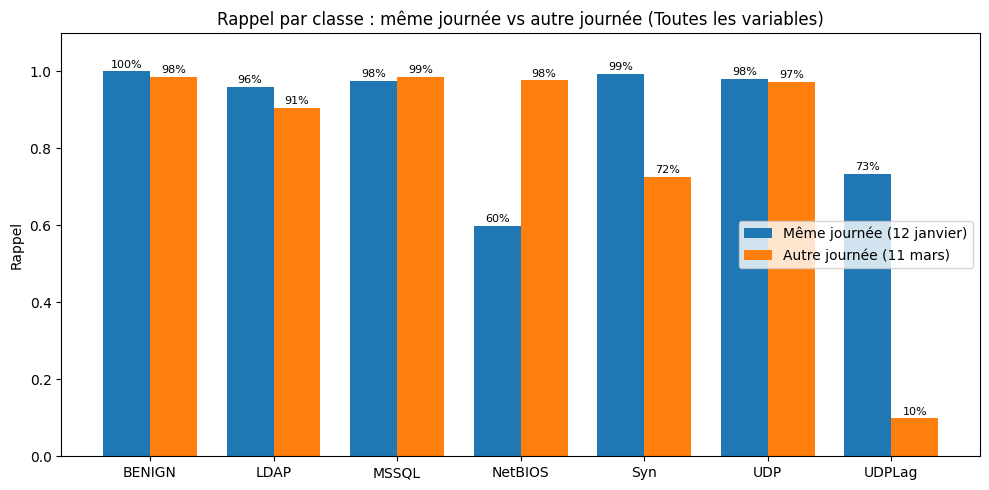


Toutes les variables : Portmap (894 flux) classé comme :
NetBIOS    0.6163
UDPLag     0.1655
MSSQL      0.1421
BENIGN     0.0246
UDP        0.0246
Syn        0.0179
LDAP       0.0089


In [70]:
# ============================================================
# GRAPHIQUE : Rappel par classe
# ============================================================
nom0 = "Toutes les variables"

g = rappel[rappel["Variante"] == nom0].set_index("Classe").loc[classes]
x = np.arange(len(classes))
h = 0.38

plt.figure(figsize=(10, 5))
plt.bar(x - h/2, g["Rappel Exp 0"], h, label="Même journée (12 janvier)")
plt.bar(x + h/2, g["Rappel Exp 1"], h, label="Autre journée (11 mars)")

for i, (a, b) in enumerate(zip(g["Rappel Exp 0"], g["Rappel Exp 1"])):
    plt.text(i - h/2, a + 0.01, f"{a:.0%}", ha="center", fontsize=8)
    plt.text(i + h/2, b + 0.01, f"{b:.0%}", ha="center", fontsize=8)

plt.xticks(x, classes)
plt.ylim(0, 1.1)
plt.ylabel("Rappel")
plt.title(f"Rappel par classe : même journée vs autre journée ({nom0})")
plt.legend()
plt.tight_layout()
plt.savefig(SORTIE / "rappel_par_classe.png", dpi=200)
plt.show()


# ============================================================
# PORTMAP : distribution
# ============================================================
if len(pred_port):
    rep = pd.Series([classes[k] for k in pred_port]).value_counts(normalize=True).round(4)
    print(f"\n{nom0} : Portmap ({len(pred_port)} flux) classé comme :")
    print(rep.to_string())

## 8. Lacune 2 : explicabilité



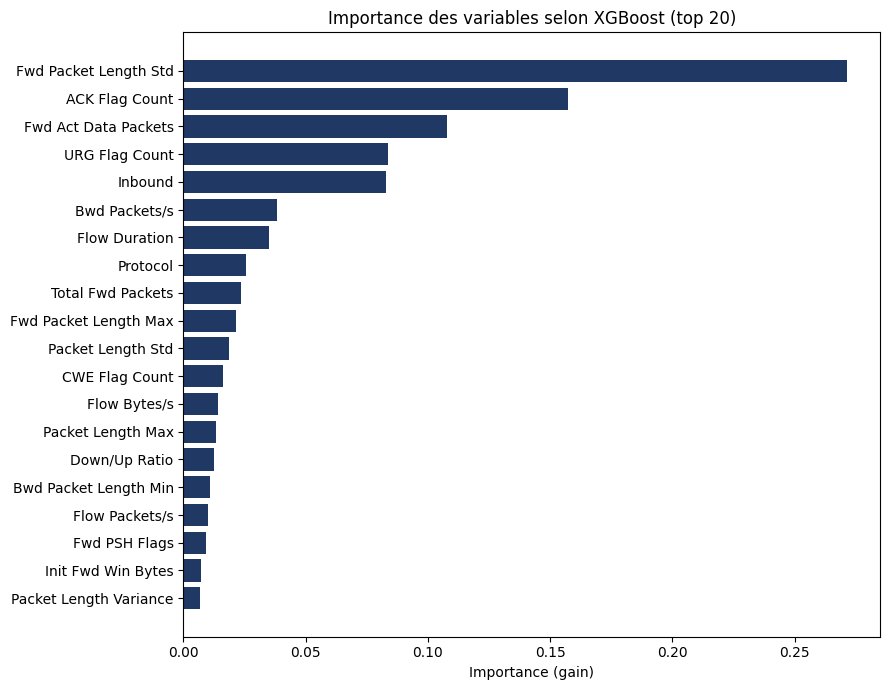

Variable la plus importante selon XGBoost : Fwd Packet Length Std


,Variable,Importance XGBoost
0,Fwd Packet Length Std,0.2714
1,ACK Flag Count,0.1574
2,Fwd Act Data Packets,0.1079
3,URG Flag Count,0.0835
4,Inbound,0.0829
5,Bwd Packets/s,0.0382
6,Flow Duration,0.0351
7,Protocol,0.0256
8,Total Fwd Packets,0.0236
9,Fwd Packet Length Max,0.0214


In [71]:
# ============================================================
# IMPORTANCE DES VARIABLES SELON XGBOOST (GAIN)
# ============================================================
imp_xgb = pd.DataFrame({
    "Variable": features,
    "Importance XGBoost": model.feature_importances_
}).sort_values("Importance XGBoost", ascending=False).reset_index(drop=True)

imp_xgb.to_csv(SORTIE / "importance_xgboost.csv", index=False, encoding="utf-8-sig")

# --- Graphique Top 20 ---
top = imp_xgb.head(20).iloc[::-1]

plt.figure(figsize=(9, 7))
plt.barh(top["Variable"], top["Importance XGBoost"], color="#1F3864")
plt.xlabel("Importance (gain)")
plt.title("Importance des variables selon XGBoost (top 20)")
plt.tight_layout()
plt.savefig(SORTIE / "importance_xgboost.png", dpi=200)
plt.show()

print("Variable la plus importante selon XGBoost :", imp_xgb.loc[0, "Variable"])
display(imp_xgb.head(15).round(4))

In [72]:
# ============================================================
# PREPARATION X_ref / X_te (à exécuter UNE FOIS)
# ============================================================
X_ref = tr[features].astype("float32").iloc[idx_ref].reset_index(drop=True)
X_te  = te[features].astype("float32").reset_index(drop=True)

print(f"X_ref : {X_ref.shape}")
print(f"X_te  : {X_te.shape}")
print(f"y_ref : {y_ref.shape}")
print(f"y_te  : {y_te.shape}")


# ============================================================
# CALCUL DES VALEURS SHAP
# ============================================================
import shap

SEED = 42
PAR_CLASSE_SHAP = 400

def echantillon(y, n):
    rng = np.random.default_rng(SEED)
    indices = []
    for k in np.unique(y):
        idx_k = np.where(y == k)[0]
        n_k = min(n, len(idx_k))
        indices.append(rng.choice(idx_k, size=n_k, replace=False))
    return np.concatenate(indices)


def calcul_shap(explainer, X):
    sv = explainer.shap_values(X)
    if isinstance(sv, list):
        sv = np.stack(sv, axis=2)
    return np.asarray(sv)


i_ref = echantillon(y_ref, PAR_CLASSE_SHAP)
i_te  = echantillon(y_te, PAR_CLASSE_SHAP)

Xs_ref, ys_ref = X_ref.iloc[i_ref].reset_index(drop=True), y_ref[i_ref]
Xs_te,  ys_te  = X_te.iloc[i_te].reset_index(drop=True),   y_te[i_te]

explainer = shap.TreeExplainer(model)

sv_ref = calcul_shap(explainer, Xs_ref)
sv_te  = calcul_shap(explainer, Xs_te)

print(f"SHAP calculé sur {len(Xs_ref)} flux (même journée) + {len(Xs_te)} flux (autre journée)")
print(f"sv_ref.shape : {sv_ref.shape}")
print(f"sv_te.shape  : {sv_te.shape}")

SHAP calculé sur 2800 flux (même journée) + 2800 flux (autre journée)


VARIABLE LA PLUS IMPORTANTE (SHAP global) : Fwd Packet Length Max
Variables communes dans le top 10 des deux journées : 9/10


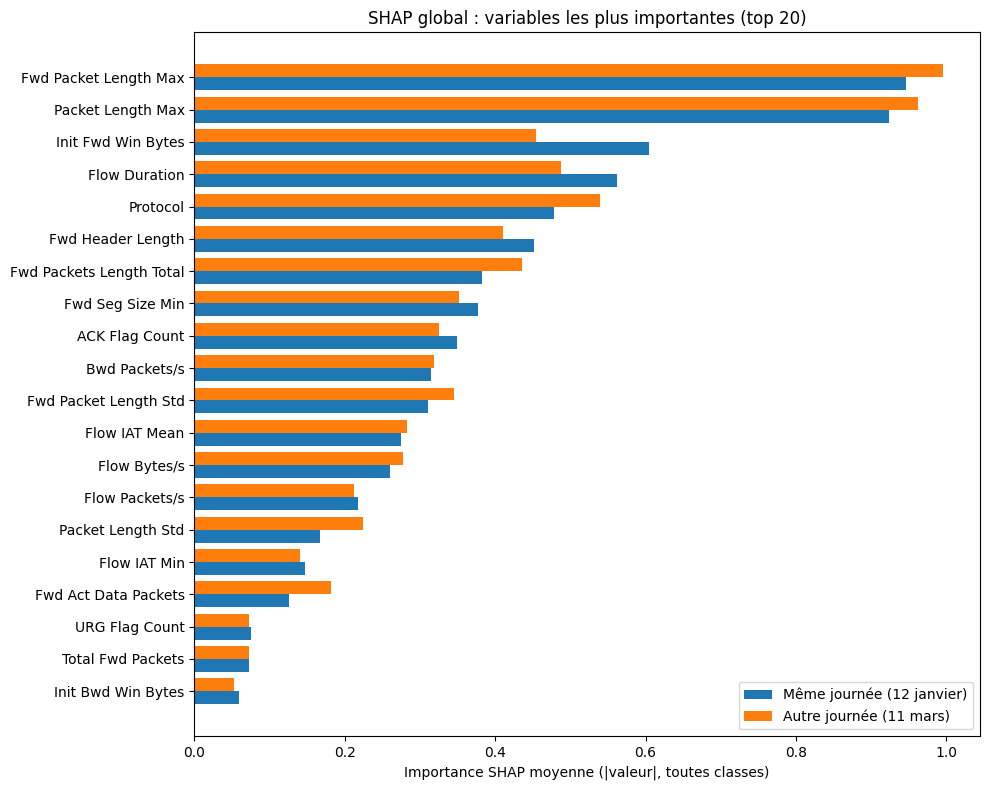

,Variable,Importance même journée,Importance autre journée,Rang même journée,Rang autre journée
0,Fwd Packet Length Max,0.9457,0.9950,1,1
1,Packet Length Max,0.9237,0.9624,2,2
2,Init Fwd Win Bytes,0.6043,0.4549,3,5
3,Flow Duration,0.5627,0.4869,4,4
4,Protocol,0.4785,0.5389,5,3
5,Fwd Header Length,0.4521,0.4100,6,7
6,Fwd Packets Length Total,0.3819,0.4362,7,6
7,Fwd Seg Size Min,0.3777,0.3522,8,8
8,ACK Flag Count,0.3495,0.3251,9,10
9,Bwd Packets/s,0.3153,0.3189,10,11


In [73]:
# ============================================================
# SHAP GLOBAL : variables les plus importantes
# ============================================================
imp_ref = np.abs(sv_ref).mean(axis=(0, 2))
imp_te  = np.abs(sv_te).mean(axis=(0, 2))

A = pd.DataFrame({
    "Variable": features,
    "Importance même journée": imp_ref,
    "Importance autre journée": imp_te
})

A["Rang même journée"]  = A["Importance même journée"].rank(ascending=False).astype(int)
A["Rang autre journée"] = A["Importance autre journée"].rank(ascending=False).astype(int)
A = A.sort_values("Rang même journée").reset_index(drop=True)

A.to_csv(SORTIE / "shap_importance_globale.csv", index=False, encoding="utf-8-sig")

commun = len(
    set(A.nsmallest(10, "Rang même journée").Variable) &
    set(A.nsmallest(10, "Rang autre journée").Variable)
)

print(f"VARIABLE LA PLUS IMPORTANTE (SHAP global) : {A.loc[0, 'Variable']}")
print(f"Variables communes dans le top 10 des deux journées : {commun}/10")

top = A.head(20).iloc[::-1]
yy = np.arange(len(top))
h = 0.4

plt.figure(figsize=(10, 8))
plt.barh(yy - h/2, top["Importance même journée"], h, label="Même journée (12 janvier)")
plt.barh(yy + h/2, top["Importance autre journée"], h, label="Autre journée (11 mars)")
plt.yticks(yy, top["Variable"])
plt.xlabel("Importance SHAP moyenne (|valeur|, toutes classes)")
plt.title("SHAP global : variables les plus importantes (top 20)")
plt.legend()
plt.tight_layout()
plt.savefig(SORTIE / "shap_global.png", dpi=200)
plt.show()

display(A.head(15).round(4))

VARIABLE LA PLUS IMPORTANTE POUR CHAQUE CLASSE :


,Classe,Variable,Importance SHAP
0,BENIGN,Bwd Packets/s,2.5481
1,LDAP,Fwd Packet Length Max,2.3522
2,MSSQL,Fwd Packet Length Max,1.0980
3,NetBIOS,Packet Length Max,2.2783
4,Syn,Flow Duration,2.5254
5,UDP,Fwd Packet Length Std,0.9999
6,UDPLag,Fwd Header Length,0.5667


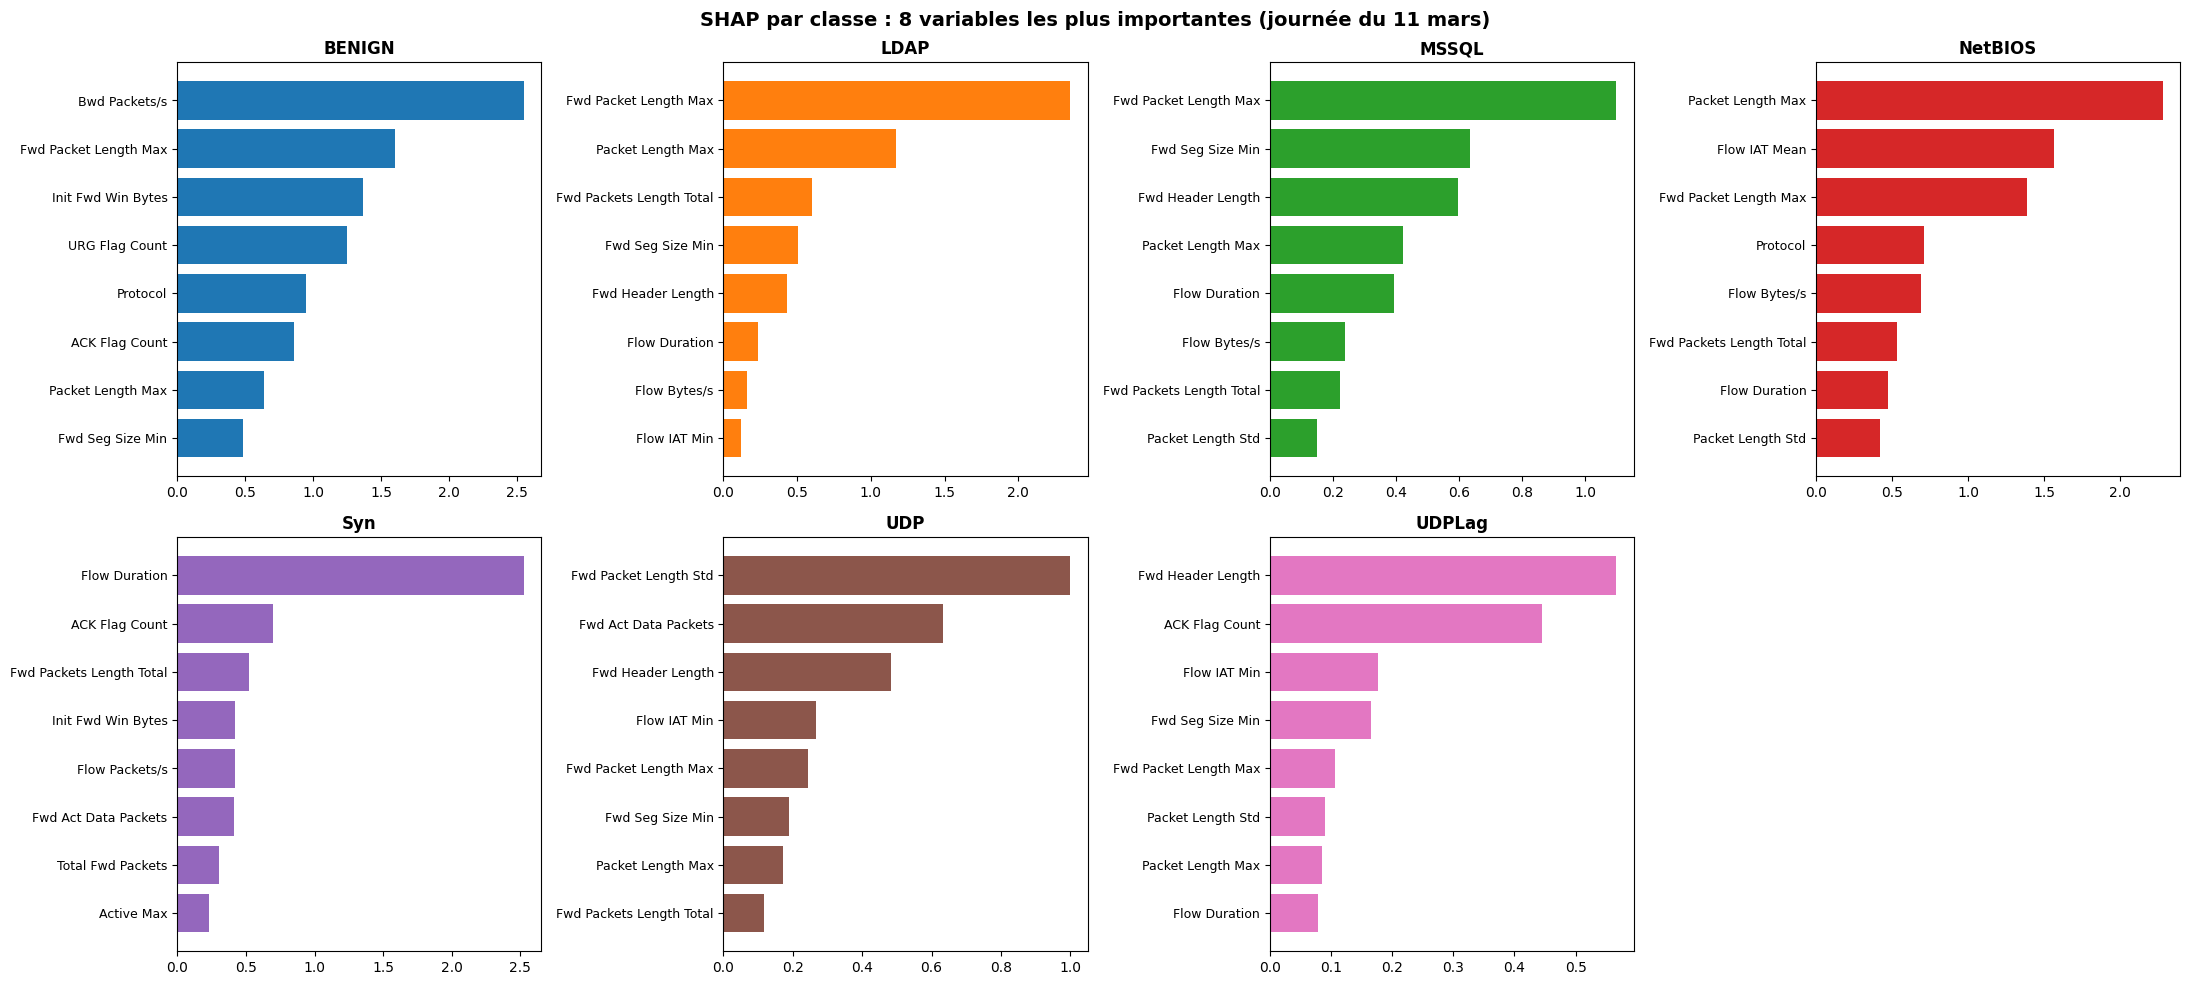

In [74]:
# ============================================================
# SHAP DE CHAQUE CLASSE
# ============================================================
imp_classe, lig = {}, []

for k, c in enumerate(classes):
    m = ys_te == k
    imp = np.abs(sv_te[m][:, :, k]).mean(axis=0)
    imp_classe[c] = imp
    for rang, j in enumerate(np.argsort(-imp)[:10], 1):
        lig.append({
            "Classe": c,
            "Rang": rang,
            "Variable": features[j],
            "Importance SHAP": imp[j]
        })

B = pd.DataFrame(lig)
B.to_csv(SORTIE / "shap_variables_par_classe.csv", index=False, encoding="utf-8-sig")

meilleures = B[B["Rang"] == 1][["Classe", "Variable", "Importance SHAP"]].reset_index(drop=True)

print("VARIABLE LA PLUS IMPORTANTE POUR CHAQUE CLASSE :")
display(meilleures.round(4))

# --- Graphique 2x4 ---
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()

for k, c in enumerate(classes):
    b = B[(B["Classe"] == c) & (B["Rang"] <= 8)].iloc[::-1]
    axes[k].barh(b["Variable"], b["Importance SHAP"], color=plt.cm.tab10(k))
    axes[k].set_title(f"{c}", fontweight="bold")
    axes[k].tick_params(axis="y", labelsize=9)

for a in axes[len(classes):]:
    a.set_visible(False)

plt.suptitle("SHAP par classe : 8 variables les plus importantes (journée du 11 mars)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(SORTIE / "shap_par_classe.png", dpi=200)
plt.show()

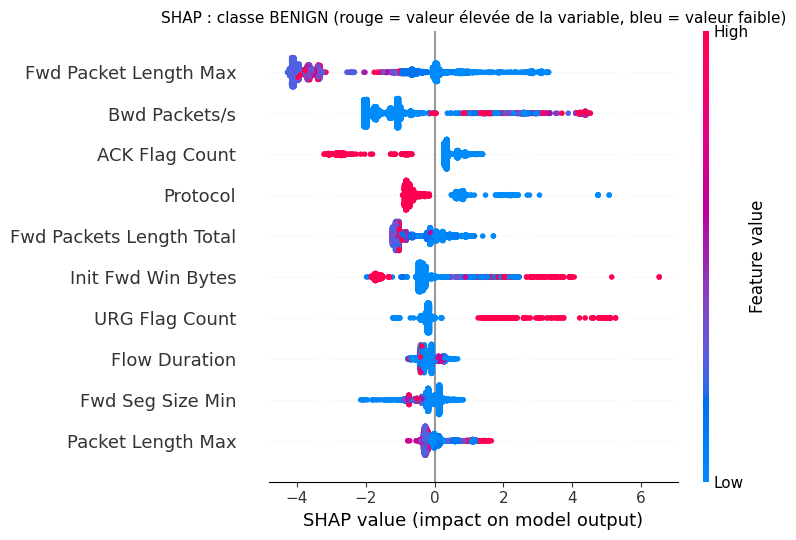

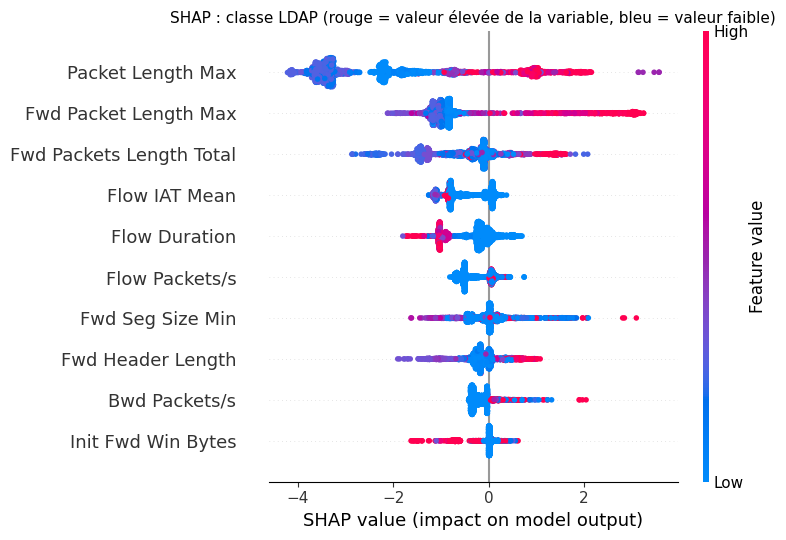

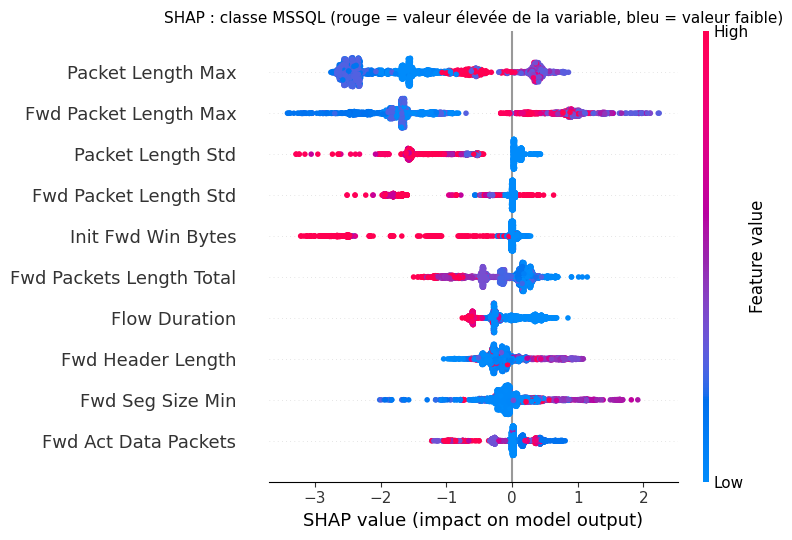

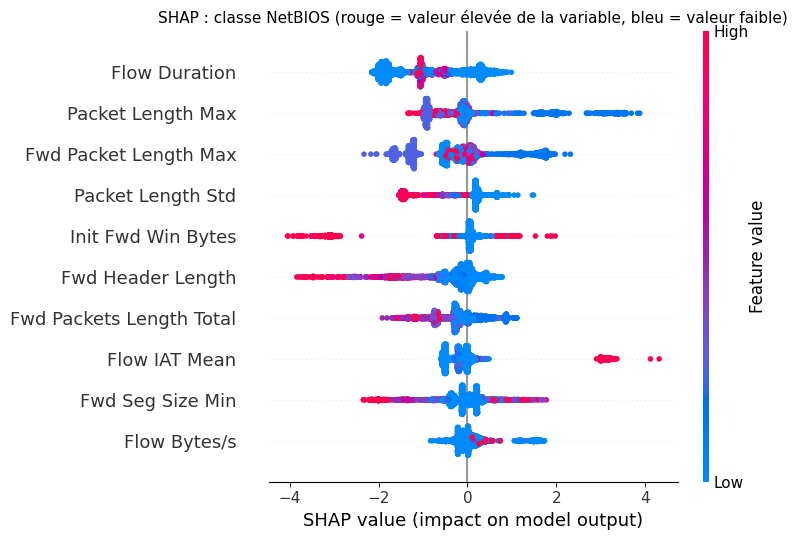

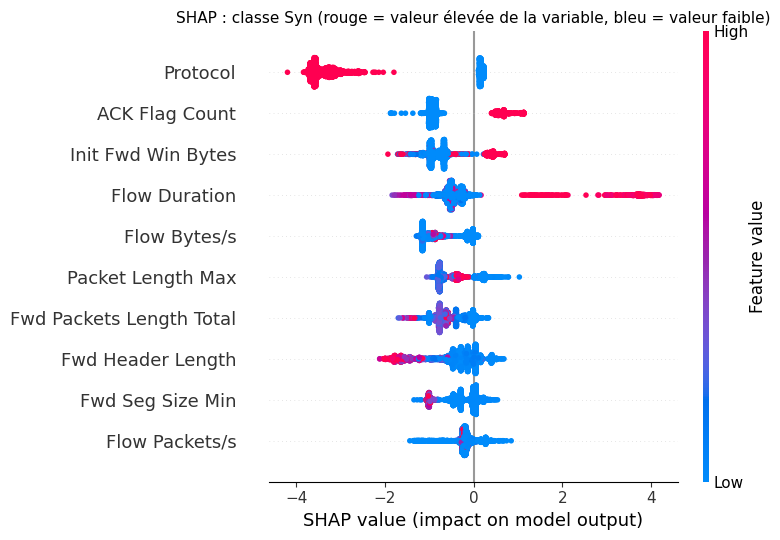

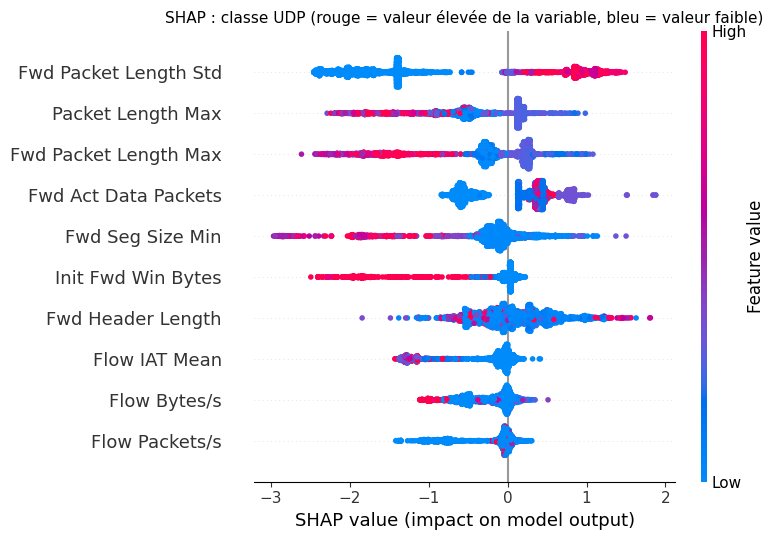

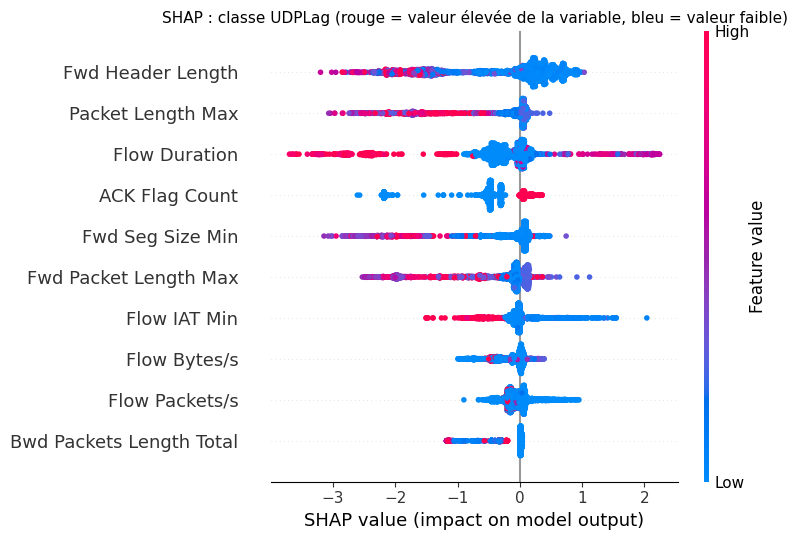

In [75]:
# ============================================================
# SHAP DETAILLE PAR CLASSE (beeswarm)
# ============================================================
if AFFICHER_BEESWARM:
    for k, c in enumerate(classes):
        plt.figure(figsize=(10, 6))
        shap.summary_plot(
            sv_te[:, :, k],
            Xs_te,
            feature_names=features,
            max_display=10,
            show=False
        )
        plt.title(
            f"SHAP : classe {c} (rouge = valeur élevée de la variable, bleu = valeur faible)",
            fontsize=11
        )
        plt.tight_layout()
        plt.savefig(SORTIE / f"shap_detail_{c}.png", dpi=200, bbox_inches="tight")
        plt.show()

In [76]:
# 8.6 Pourquoi la classe la plus touchee par le changement de journee echoue
rap = rappel[rappel["Variante"] == nom0].set_index("Classe")
pire = rap["Écart"].idxmin(); k = classes.index(pire)
print(f"Classe la plus touchée : {pire} (rappel {rap.loc[pire, 'Rappel Exp 0']:.1%} -> {rap.loc[pire, 'Rappel Exp 1']:.1%})")
m_ref, m_te = ys_ref == k, ys_te == k
s_ref = sv_ref[m_ref][:, :, k].mean(axis=0); s_te = sv_te[m_te][:, :, k].mean(axis=0)
C = pd.DataFrame({"Variable": feats,
                  f"Contribution vers {pire} (même journée)": s_ref,
                  f"Contribution vers {pire} (autre journée)": s_te,
                  "Écart de contribution": s_te - s_ref,
                  "Valeur médiane (même journée)": np.median(Xs_ref[m_ref], axis=0),
                  "Valeur médiane (autre journée)": np.median(Xs_te[m_te], axis=0)})
C = C.reindex(C["Écart de contribution"].abs().sort_values(ascending=False).index).head(15).reset_index(drop=True)
C.to_csv(SORTIE / "shap_classe_faible.csv", index=False, encoding="utf-8-sig")
display(C.round(4))
vers = pd.Series([classes[q] for q in r["p1"][r["y1"] == k]]).value_counts(normalize=True).round(4)
print(f"\nOù vont les flux {pire} de la journée du 11 mars :"); print(vers.to_string())

Classe la plus touchée : UDPLag (rappel 73.3% -> 9.8%)


,Variable,Contribution vers UDPLag (même journée),Contribution vers UDPLag (autre journée),Écart de contribution,Valeur médiane (même journée),Valeur médiane (autre journée)
0,Flow Duration,1.0821,0.0427,-1.0394,2.593907e+07,108959.500000
1,Fwd Header Length,0.7513,0.0425,-0.7089,1.200000e+02,80.000000
2,ACK Flag Count,0.0517,-0.4436,-0.4953,1.000000e+00,0.000000
3,Flow Packets/s,0.2885,0.0366,-0.2519,2.447000e-01,36.710899
4,Fwd Seg Size Min,0.0913,-0.0565,-0.1477,2.000000e+01,14.000000
5,Init Fwd Win Bytes,0.0595,-0.0747,-0.1341,5.840000e+03,0.000000
6,Fwd Packet Length Max,0.0086,0.1024,0.0938,0.000000e+00,389.000000
7,Flow IAT Mean,0.1381,0.0452,-0.0930,4.812929e+06,36319.835938
8,Flow IAT Min,-0.0053,0.0863,0.0916,1.000000e+00,1.000000
9,Idle Std,0.0645,-0.0097,-0.0741,8.471988e+04,0.000000



Où vont les flux UDPLag de la journée du 11 mars :
UDP        0.8981
UDPLag     0.0966
MSSQL      0.0035
NetBIOS    0.0012
BENIGN     0.0004
Syn        0.0002
LDAP       0.0000
